In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report,roc_auc_score

In [2]:



# 1. Load file
with open("chronic_kidney_disease.arff", "r") as f:
    lines = f.readlines()

# 2. Extract data section
data_start = False
rows = []

for line in lines:
    line = line.strip()

    if line.lower().startswith("@data"):
        data_start = True
        continue

    if not data_start or line == "":
        continue

    row = [x.strip() for x in line.split(",")]

    rows.append(row)

# 3. DEBUG: check actual structure
print("Example row length:", len(rows[0]))
print("First row:", rows[0])

# 4. Define correct column names (26 columns)
columns = [
    "age","bp","sg","al","su",
    "rbc","pc","pcc","ba",
    "bgr","bu","sc","sod","pot",
    "hemo","pcv","wbcc","rbcc",
    "htn","dm","cad","appet","pe","ane",
    "class"
]

print("Column count:", len(columns))

# 5. HARD FIX: only keep valid rows
clean_rows = []

for r in rows:
    if len(r) == len(columns):
        clean_rows.append(r)
    else:
        print("Skipping bad row:", len(r), r)

# 6. Create DataFrame safely
df = pd.DataFrame(clean_rows, columns=columns)

# 7. Clean missing values
df = df.replace("?", np.nan)

# 8. Strip whitespace everywhere
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# 9. Convert numeric columns
num_cols = [
    "age","bp","sg","al","su","bgr","bu","sc",
    "sod","pot","hemo","pcv","wbcc","rbcc"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.head())
print(df.info())

Example row length: 25
First row: ['48', '80', '1.020', '1', '0', '?', 'normal', 'notpresent', 'notpresent', '121', '36', '1.2', '?', '?', '15.4', '44', '7800', '5.2', 'yes', 'yes', 'no', 'good', 'no', 'no', 'ckd']
Column count: 25
Skipping bad row: 26 ['26', '70', '1.015', '0', '4', '?', 'normal', 'notpresent', 'notpresent', '250', '20', '1.1', '?', '?', '15.6', '52', '6900', '6.0', 'no', 'yes', 'no', 'good', 'no', 'no', 'ckd', '']
Skipping bad row: 26 ['64', '90', '1.010', '3', '3', '?', 'abnormal', 'present', 'notpresent', '?', '35', '1.3', '?', '?', '10.3', '?', '?', '?', 'yes', 'yes', 'no', 'good', 'yes', 'no', 'ckd', '']
Skipping bad row: 26 ['75', '70', '1.020', '0', '0', 'normal', 'normal', 'notpresent', 'notpresent', '107', '48', '0.8', '144', '3.5', '13.6', '46', '10300', '4.8', 'no', '', 'no', 'no', 'good', 'no', 'no', 'notckd']
    age    bp     sg   al   su     rbc        pc         pcc          ba  \
0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent

C:\Users\Stijn\AppData\Local\Temp\ipykernel_35244\3641893720.py:55: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [3]:
#EDA and fixing null values 

In [4]:
df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
393,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
394,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
395,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


In [5]:
df = df.fillna(df.mean(numeric_only=True)) #replacing numeric null values with the mean 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     397 non-null    float64
 1   bp      397 non-null    float64
 2   sg      397 non-null    float64
 3   al      397 non-null    float64
 4   su      397 non-null    float64
 5   rbc     247 non-null    object 
 6   pc      332 non-null    object 
 7   pcc     393 non-null    object 
 8   ba      393 non-null    object 
 9   bgr     397 non-null    float64
 10  bu      397 non-null    float64
 11  sc      397 non-null    float64
 12  sod     397 non-null    float64
 13  pot     397 non-null    float64
 14  hemo    397 non-null    float64
 15  pcv     397 non-null    float64
 16  wbcc    397 non-null    float64
 17  rbcc    397 non-null    float64
 18  htn     395 non-null    object 
 19  dm      395 non-null    object 
 20  cad     395 non-null    object 
 21  appet   396 non-null    object 
 22  pe

In [7]:
#Because every abnormal rbc shows that the class is ckd i will make it when class = rbc.fillna(abnormal) when class = ckd 
df[df["rbc"] == 'abnormal']

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
9,53.000000,90.000000,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,70.000000,...,29.00000,12100.000000,3.700000,yes,yes,no,poor,no,yes,ckd
11,63.000000,70.000000,1.010,3.0,0.0,abnormal,abnormal,present,notpresent,380.000000,...,32.00000,4500.000000,3.800000,yes,yes,no,poor,yes,no,ckd
20,61.000000,80.000000,1.015,2.0,0.0,abnormal,abnormal,notpresent,notpresent,173.000000,...,24.00000,9200.000000,3.200000,yes,yes,yes,poor,yes,yes,ckd
29,68.000000,70.000000,1.005,1.0,0.0,abnormal,abnormal,present,notpresent,147.864407,...,38.00000,8404.794521,4.702247,no,no,yes,good,no,no,ckd
33,60.000000,100.000000,1.020,2.0,0.0,abnormal,abnormal,notpresent,notpresent,140.000000,...,29.00000,8404.794521,4.702247,yes,no,no,poor,no,no,ckd
35,65.000000,90.000000,1.020,2.0,1.0,abnormal,normal,notpresent,notpresent,270.000000,...,36.00000,9800.000000,4.900000,yes,yes,no,poor,no,yes,ckd
38,69.000000,80.000000,1.020,3.0,0.0,abnormal,normal,notpresent,notpresent,147.864407,...,38.82263,8404.794521,4.702247,yes,no,no,good,no,no,ckd
43,35.000000,80.000000,1.010,1.0,0.0,abnormal,NaN,notpresent,notpresent,79.000000,...,24.00000,7900.000000,3.100000,no,yes,no,good,no,no,ckd
44,54.000000,80.000000,1.010,3.0,0.0,abnormal,abnormal,notpresent,notpresent,207.000000,...,28.00000,8404.794521,4.702247,yes,yes,no,poor,yes,no,ckd
55,35.000000,80.000000,1.005,3.0,0.0,abnormal,normal,notpresent,notpresent,147.864407,...,28.00000,8404.794521,4.702247,no,no,no,good,yes,no,ckd


In [8]:
df['rbc'].value_counts()

rbc
normal      200
abnormal     47
Name: count, dtype: int64

In [9]:
df.loc[(df["class"] == "ckd") & (df["rbc"].isna()), "rbc"] = "abnormal"
df.loc[(df["class"] == "notckd") & (df["rbc"].isna()), "rbc"] = "normal"


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     397 non-null    float64
 1   bp      397 non-null    float64
 2   sg      397 non-null    float64
 3   al      397 non-null    float64
 4   su      397 non-null    float64
 5   rbc     397 non-null    object 
 6   pc      332 non-null    object 
 7   pcc     393 non-null    object 
 8   ba      393 non-null    object 
 9   bgr     397 non-null    float64
 10  bu      397 non-null    float64
 11  sc      397 non-null    float64
 12  sod     397 non-null    float64
 13  pot     397 non-null    float64
 14  hemo    397 non-null    float64
 15  pcv     397 non-null    float64
 16  wbcc    397 non-null    float64
 17  rbcc    397 non-null    float64
 18  htn     395 non-null    object 
 19  dm      395 non-null    object 
 20  cad     395 non-null    object 
 21  appet   396 non-null    object 
 22  pe

In [11]:
#come back here if you wanna try correct some more null values 

In [12]:
df = df.dropna(axis = 0)

In [13]:
df_count = df[df['rbc'] == 'normal']
df_count['class'].value_counts()

class
notckd    134
ckd        53
Name: count, dtype: int64

In [14]:
df[df.isna().any(axis=1)]

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 326 entries, 0 to 396
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     326 non-null    float64
 1   bp      326 non-null    float64
 2   sg      326 non-null    float64
 3   al      326 non-null    float64
 4   su      326 non-null    float64
 5   rbc     326 non-null    object 
 6   pc      326 non-null    object 
 7   pcc     326 non-null    object 
 8   ba      326 non-null    object 
 9   bgr     326 non-null    float64
 10  bu      326 non-null    float64
 11  sc      326 non-null    float64
 12  sod     326 non-null    float64
 13  pot     326 non-null    float64
 14  hemo    326 non-null    float64
 15  pcv     326 non-null    float64
 16  wbcc    326 non-null    float64
 17  rbcc    326 non-null    float64
 18  htn     326 non-null    object 
 19  dm      326 non-null    object 
 20  cad     326 non-null    object 
 21  appet   326 non-null    object 
 22  pe     

In [16]:
df_edit = df.copy()
df_edit['ed']= df['sod']/df['pot']

In [17]:
df_edit

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class,ed
0,48.0,80.0,1.020,1.0,0.0,abnormal,normal,notpresent,notpresent,121.000000,...,7800.0,5.200000,yes,yes,no,good,no,no,ckd,29.693787
1,7.0,50.0,1.020,4.0,0.0,abnormal,normal,notpresent,notpresent,147.864407,...,6000.0,4.702247,no,no,no,good,no,no,ckd,29.693787
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.000000,...,7500.0,4.702247,no,yes,no,poor,no,yes,ckd,29.693787
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.000000,...,6700.0,3.900000,yes,no,no,poor,yes,yes,ckd,44.400000
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.000000,...,7300.0,4.600000,no,no,no,good,no,no,ckd,29.693787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.000000,...,6700.0,4.900000,no,no,no,good,no,no,notckd,30.612245
393,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.000000,...,7800.0,6.200000,no,no,no,good,no,no,notckd,40.285714
394,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.000000,...,6600.0,5.400000,no,no,no,good,no,no,notckd,31.136364
395,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.000000,...,7200.0,5.900000,no,no,no,good,no,no,notckd,27.551020


In [18]:
df_edit.info()

<class 'pandas.core.frame.DataFrame'>
Index: 326 entries, 0 to 396
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     326 non-null    float64
 1   bp      326 non-null    float64
 2   sg      326 non-null    float64
 3   al      326 non-null    float64
 4   su      326 non-null    float64
 5   rbc     326 non-null    object 
 6   pc      326 non-null    object 
 7   pcc     326 non-null    object 
 8   ba      326 non-null    object 
 9   bgr     326 non-null    float64
 10  bu      326 non-null    float64
 11  sc      326 non-null    float64
 12  sod     326 non-null    float64
 13  pot     326 non-null    float64
 14  hemo    326 non-null    float64
 15  pcv     326 non-null    float64
 16  wbcc    326 non-null    float64
 17  rbcc    326 non-null    float64
 18  htn     326 non-null    object 
 19  dm      326 non-null    object 
 20  cad     326 non-null    object 
 21  appet   326 non-null    object 
 22  pe     

In [19]:
#checking corr 
df_encoded = pd.get_dummies(df_edit)

In [20]:
pd.set_option('display.max_columns', None)
df_encoded.corr()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,ed,rbc_abnormal,rbc_normal,pc_abnormal,pc_normal,pcc_notpresent,pcc_present,ba_notpresent,ba_present,htn_no,htn_yes,dm_no,dm_yes,cad_no,cad_yes,appet_good,appet_poor,pe_no,pe_yes,ane_no,ane_yes,class_ckd,class_notckd
age,1.000000,0.181754,-0.193678,0.111412,0.223852,0.243431,0.209211,0.169108,-0.109635,0.052822,-0.182998,-0.213287,0.110819,-0.200078,-0.092411,0.158762,-0.158762,0.147615,-0.147615,-0.189162,0.189162,-0.053680,0.053680,-0.408110,0.408110,-0.359187,0.359187,-0.247060,0.247060,-0.198883,0.198883,-0.117610,0.117610,-0.045297,0.045297,0.223013,-0.223013
bp,0.181754,1.000000,-0.172811,0.143680,0.207144,0.137836,0.163189,0.178208,-0.075579,0.069799,-0.233954,-0.264245,0.042232,-0.175325,-0.105252,0.260792,-0.260792,0.175613,-0.175613,-0.065867,0.065867,-0.135464,0.135464,-0.252131,0.252131,-0.204557,0.204557,-0.087561,0.087561,-0.204362,0.204362,-0.080832,0.080832,-0.184465,0.184465,0.285930,-0.285930
sg,-0.193678,-0.172811,1.000000,-0.461460,-0.281030,-0.348856,-0.288977,-0.339419,0.363993,-0.070681,0.575309,0.572502,-0.204511,0.498366,0.145532,-0.493447,0.493447,-0.364388,0.364388,0.290640,-0.290640,0.221398,-0.221398,0.403618,-0.403618,0.420276,-0.420276,0.170539,-0.170539,0.270719,-0.270719,0.302051,-0.302051,0.256590,-0.256590,-0.724437,0.724437
al,0.111412,0.143680,-0.461460,1.000000,0.297920,0.369521,0.456632,0.392331,-0.417572,0.120477,-0.606765,-0.581183,0.211969,-0.484308,-0.222650,0.239936,-0.239936,0.550212,-0.550212,-0.406969,0.406969,-0.385833,0.385833,-0.510170,0.510170,-0.413799,0.413799,-0.265438,0.265438,-0.369402,0.369402,-0.470905,0.470905,-0.327360,0.327360,0.628895,-0.628895
su,0.223852,0.207144,-0.281030,0.297920,1.000000,0.707442,0.199582,0.250493,-0.106693,0.202909,-0.223667,-0.245230,0.150008,-0.215749,-0.158801,0.189875,-0.189875,0.196309,-0.196309,-0.168926,0.168926,-0.138129,0.138129,-0.316683,0.316683,-0.516691,0.516691,-0.304437,0.304437,-0.125728,0.125728,-0.169063,0.169063,-0.100265,0.100265,0.325807,-0.325807
bgr,0.243431,0.137836,-0.348856,0.369521,0.707442,1.000000,0.174416,0.147891,-0.219299,0.064420,-0.307212,-0.309037,0.125019,-0.257748,-0.111630,0.265879,-0.265879,0.302543,-0.302543,-0.225456,0.225456,-0.095424,0.095424,-0.421247,0.421247,-0.560959,0.560959,-0.282125,0.282125,-0.230254,0.230254,-0.155785,0.155785,-0.153076,0.153076,0.415783,-0.415783
bu,0.209211,0.163189,-0.288977,0.456632,0.199582,0.174416,1.000000,0.804044,-0.301859,0.382704,-0.527693,-0.529399,0.041688,-0.482759,-0.387313,0.123628,-0.123628,0.428156,-0.428156,-0.218264,0.218264,-0.170985,0.170985,-0.410082,0.410082,-0.337947,0.337947,-0.255021,0.255021,-0.332462,0.332462,-0.417355,0.417355,-0.439890,0.439890,0.364474,-0.364474
sc,0.169108,0.178208,-0.339419,0.392331,0.250493,0.147891,0.804044,1.000000,-0.333852,0.350359,-0.475475,-0.484633,0.026547,-0.427222,-0.341640,0.174033,-0.174033,0.348418,-0.348418,-0.132740,0.132740,-0.113835,0.113835,-0.326614,0.326614,-0.278178,0.278178,-0.164599,0.164599,-0.262432,0.262432,-0.382842,0.382842,-0.382451,0.382451,0.384365,-0.384365
sod,-0.109635,-0.075579,0.363993,-0.417572,-0.106693,-0.219299,-0.301859,-0.333852,1.000000,0.109673,0.458316,0.470965,-0.066455,0.410042,0.128898,-0.271267,0.271267,-0.309020,0.309020,0.249719,-0.249719,0.145384,-0.145384,0.410517,-0.410517,0.322858,-0.322858,0.178275,-0.178275,0.299085,-0.299085,0.285792,-0.285792,0.317385,-0.317385,-0.459847,0.459847
pot,0.052822,0.069799,-0.070681,0.120477,0.202909,0.064420,0.382704,0.350359,0.109673,1.000000,-0.113408,-0.131487,-0.070338,-0.130340,-0.574974,-0.046442,0.046442,0.157720,-0.157720,0.011394,-0.011394,0.006234,-0.006234,-0.067227,0.067227,-0.069547,0.069547,-0.005986,0.005986,0.017885,-0.017885,-0.083862,0.083862,-0.107446,0.107446,0.090505,-0.090505


In [21]:
df_classless = df_edit.drop('class',axis = 1)
df_dummies = pd.get_dummies(df_classless)

In [22]:
df_dummies

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,ed,rbc_abnormal,rbc_normal,pc_abnormal,pc_normal,pcc_notpresent,pcc_present,ba_notpresent,ba_present,htn_no,htn_yes,dm_no,dm_yes,cad_no,cad_yes,appet_good,appet_poor,pe_no,pe_yes,ane_no,ane_yes
0,48.0,80.0,1.020,1.0,0.0,121.000000,36.0,1.2,137.508013,4.630868,15.4,44.0,7800.0,5.200000,29.693787,True,False,False,True,True,False,True,False,False,True,False,True,True,False,True,False,True,False,True,False
1,7.0,50.0,1.020,4.0,0.0,147.864407,18.0,0.8,137.508013,4.630868,11.3,38.0,6000.0,4.702247,29.693787,True,False,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False
2,62.0,80.0,1.010,2.0,3.0,423.000000,53.0,1.8,137.508013,4.630868,9.6,31.0,7500.0,4.702247,29.693787,False,True,False,True,True,False,True,False,True,False,False,True,True,False,False,True,True,False,False,True
3,48.0,70.0,1.005,4.0,0.0,117.000000,56.0,3.8,111.000000,2.500000,11.2,32.0,6700.0,3.900000,44.400000,False,True,True,False,False,True,True,False,False,True,True,False,True,False,False,True,False,True,False,True
4,51.0,80.0,1.010,2.0,0.0,106.000000,26.0,1.4,137.508013,4.630868,11.6,35.0,7300.0,4.600000,29.693787,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,55.0,80.0,1.020,0.0,0.0,140.000000,49.0,0.5,150.000000,4.900000,15.7,47.0,6700.0,4.900000,30.612245,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False
393,42.0,70.0,1.025,0.0,0.0,75.000000,31.0,1.2,141.000000,3.500000,16.5,54.0,7800.0,6.200000,40.285714,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False
394,12.0,80.0,1.020,0.0,0.0,100.000000,26.0,0.6,137.000000,4.400000,15.8,49.0,6600.0,5.400000,31.136364,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False
395,17.0,60.0,1.025,0.0,0.0,114.000000,50.0,1.0,135.000000,4.900000,14.2,51.0,7200.0,5.900000,27.551020,False,True,False,True,True,False,True,False,True,False,True,False,True,False,True,False,True,False,True,False


In [23]:
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 326 entries, 0 to 396
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             326 non-null    float64
 1   bp              326 non-null    float64
 2   sg              326 non-null    float64
 3   al              326 non-null    float64
 4   su              326 non-null    float64
 5   bgr             326 non-null    float64
 6   bu              326 non-null    float64
 7   sc              326 non-null    float64
 8   sod             326 non-null    float64
 9   pot             326 non-null    float64
 10  hemo            326 non-null    float64
 11  pcv             326 non-null    float64
 12  wbcc            326 non-null    float64
 13  rbcc            326 non-null    float64
 14  ed              326 non-null    float64
 15  rbc_abnormal    326 non-null    bool   
 16  rbc_normal      326 non-null    bool   
 17  pc_abnormal     326 non-null    bool   


In [24]:
#Assign Values 

In [25]:
#notes seems like some of the variables give away the solution too easily so gonna remove a few 
df_removed = df_edit.drop(columns =['rbc','sg','hemo','pcv','rbcc'],axis =1)
df_classless = df_removed.drop('class',axis = 1)
df_dummies = pd.get_dummies(df_classless)

In [26]:
X = df_dummies
y = df_removed['class']

In [27]:
y.info()

<class 'pandas.core.series.Series'>
Index: 326 entries, 0 to 396
Series name: class
Non-Null Count  Dtype 
--------------  ----- 
326 non-null    object
dtypes: object(1)
memory usage: 5.1+ KB


In [28]:
y.value_counts()

class
ckd       192
notckd    134
Name: count, dtype: int64

In [29]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state=42)


In [30]:
y_test.unique()

array(['notckd', 'ckd'], dtype=object)

In [31]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 27 to 131
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             195 non-null    float64
 1   bp              195 non-null    float64
 2   al              195 non-null    float64
 3   su              195 non-null    float64
 4   bgr             195 non-null    float64
 5   bu              195 non-null    float64
 6   sc              195 non-null    float64
 7   sod             195 non-null    float64
 8   pot             195 non-null    float64
 9   wbcc            195 non-null    float64
 10  ed              195 non-null    float64
 11  pc_abnormal     195 non-null    bool   
 12  pc_normal       195 non-null    bool   
 13  pcc_notpresent  195 non-null    bool   
 14  pcc_present     195 non-null    bool   
 15  ba_notpresent   195 non-null    bool   
 16  ba_present      195 non-null    bool   
 17  htn_no          195 non-null    bool   

In [32]:
# get models ready 

In [33]:
scaler = StandardScaler()

In [34]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
forest = RandomForestClassifier()

In [36]:
#Logistic 
lr = LogisticRegression()

In [37]:
lr.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
lr_test_pred = lr.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(y_test, lr_test_pred))

Test accuracy: 0.9541984732824428


In [39]:
print(classification_report(y_test, lr_test_pred))

              precision    recall  f1-score   support

         ckd       1.00      0.93      0.96        86
      notckd       0.88      1.00      0.94        45

    accuracy                           0.95       131
   macro avg       0.94      0.97      0.95       131
weighted avg       0.96      0.95      0.95       131



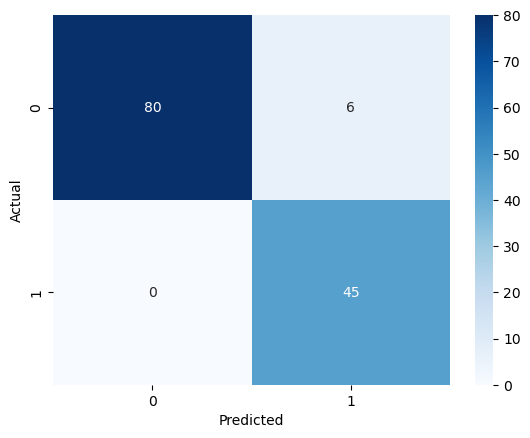

In [40]:
cm = confusion_matrix(y_test,lr_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC AUC: 0.9930232558139536


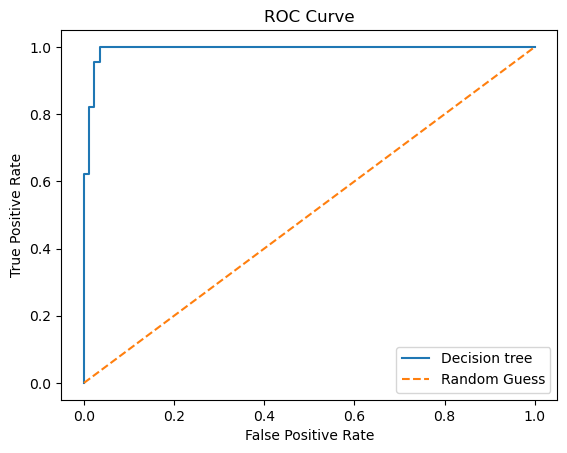

In [41]:
lr_proba_test = lr.predict_proba(X_test_scaled)[:, 1]


auc = roc_auc_score(y_test, lr_proba_test)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, lr_proba_test,pos_label='notckd')

plt.plot(fpr, tpr, label="Decision tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [42]:
svc = SVC()

In [43]:
svc.fit(X_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [44]:
svc_test_pred = lr.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(y_test, svc_test_pred))

Test accuracy: 0.9541984732824428


In [45]:
print(classification_report(y_test, svc_test_pred))

              precision    recall  f1-score   support

         ckd       1.00      0.93      0.96        86
      notckd       0.88      1.00      0.94        45

    accuracy                           0.95       131
   macro avg       0.94      0.97      0.95       131
weighted avg       0.96      0.95      0.95       131



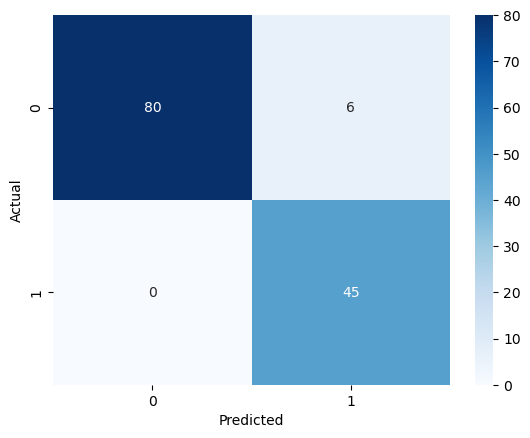

In [46]:
cm = confusion_matrix(y_test,svc_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC AUC: 0.9837209302325582


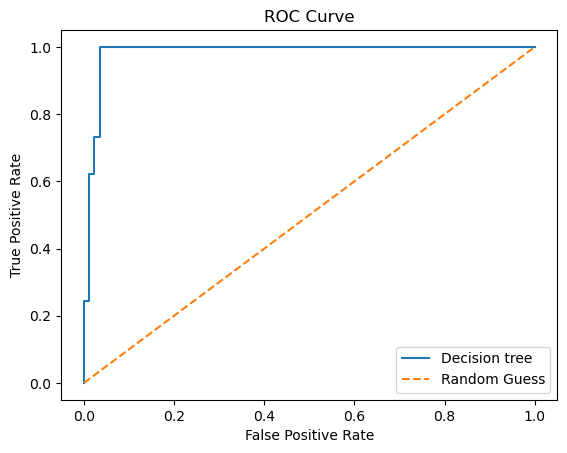

In [47]:


svc_scores = svc.decision_function(X_test_scaled)

#
auc = roc_auc_score(y_test, svc_scores)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, svc_scores,pos_label='notckd')

plt.plot(fpr, tpr, label="Decision tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [48]:
#Uhhhh i will still try with other models just to see what else i can do 

In [49]:
#kneighboursclassifer

In [50]:
kclass = KNeighborsClassifier()

In [51]:
kclass.fit(X_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [52]:
kclass_test_pred = kclass.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(y_test, kclass_test_pred))

Test accuracy: 0.8854961832061069


In [53]:
print(classification_report(y_test, kclass_test_pred))

              precision    recall  f1-score   support

         ckd       1.00      0.83      0.90        86
      notckd       0.75      1.00      0.86        45

    accuracy                           0.89       131
   macro avg       0.88      0.91      0.88       131
weighted avg       0.91      0.89      0.89       131



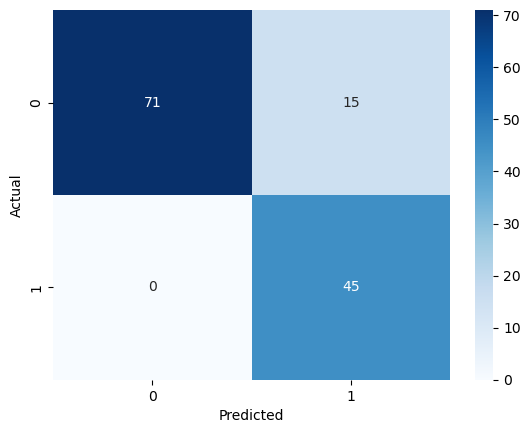

In [54]:
cm = confusion_matrix(y_test,kclass_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC AUC: 0.9829457364341085


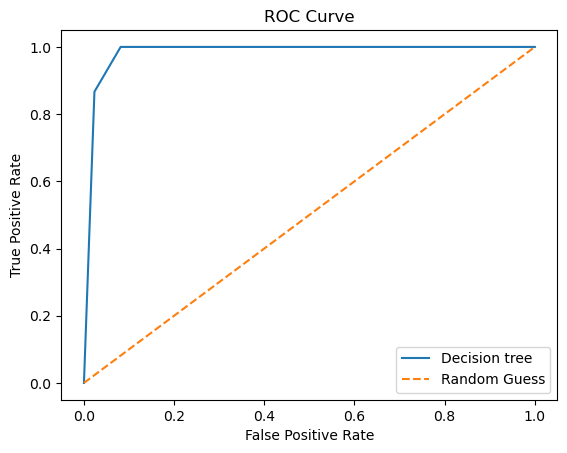

In [55]:
kclass_proba_test = kclass.predict_proba(X_test_scaled)[:, 1]


auc = roc_auc_score(y_test, kclass_proba_test)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, kclass_proba_test,pos_label='notckd')

plt.plot(fpr, tpr, label="Decision tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [56]:
dclass = DecisionTreeClassifier()

In [57]:
dclass.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [58]:
dclass_test_pred = dclass.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, dclass_test_pred))

Test accuracy: 0.9236641221374046


In [59]:
print(classification_report(y_test, dclass_test_pred))

              precision    recall  f1-score   support

         ckd       0.96      0.92      0.94        86
      notckd       0.86      0.93      0.89        45

    accuracy                           0.92       131
   macro avg       0.91      0.93      0.92       131
weighted avg       0.93      0.92      0.92       131



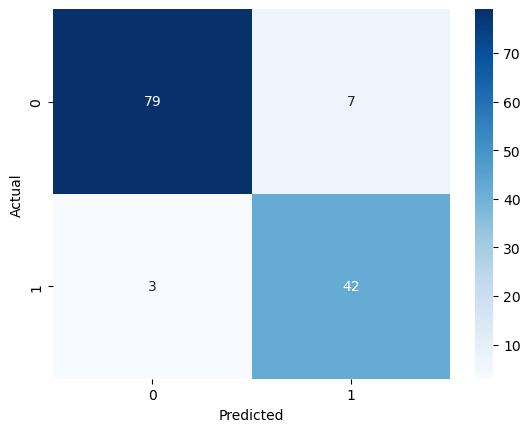

In [60]:
cm = confusion_matrix(y_test,dclass_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC AUC: 0.925968992248062


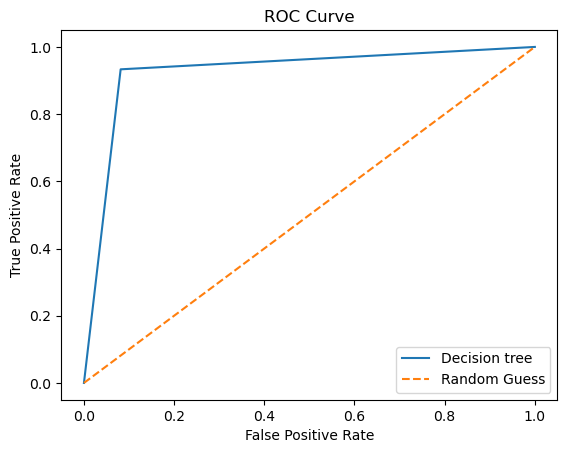

In [61]:
dclass_proba_test = dclass.predict_proba(X_test)[:, 1]


auc = roc_auc_score(y_test, dclass_proba_test)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, dclass_proba_test,pos_label='notckd')

plt.plot(fpr, tpr, label="Decision tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [98]:
forest = RandomForestClassifier()

In [99]:
forest.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
forest_test_pred = forest.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, forest_test_pred))

Test accuracy: 0.9694656488549618


In [101]:
print(classification_report(y_test, forest_test_pred))

              precision    recall  f1-score   support

         ckd       1.00      0.95      0.98        86
      notckd       0.92      1.00      0.96        45

    accuracy                           0.97       131
   macro avg       0.96      0.98      0.97       131
weighted avg       0.97      0.97      0.97       131



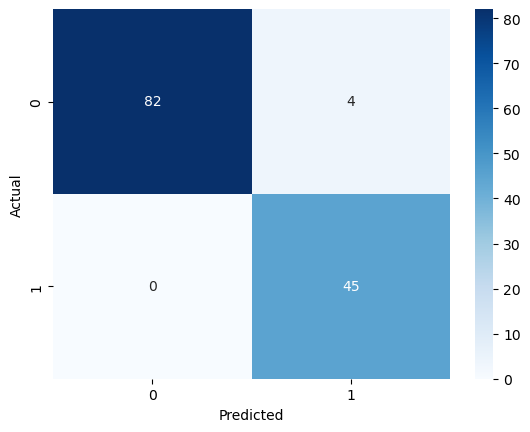

In [102]:
cm = confusion_matrix(y_test,forest_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC AUC: 0.9994832041343669


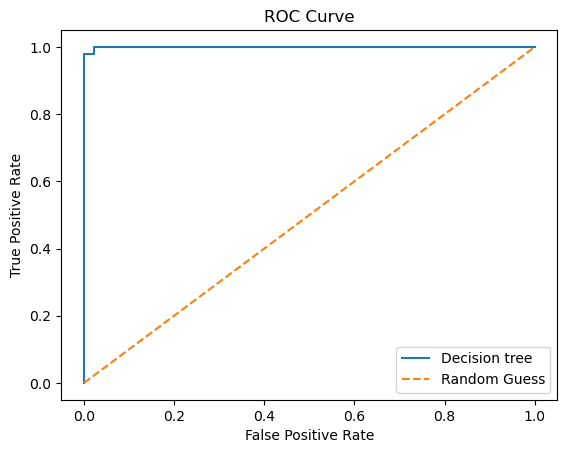

In [67]:
forest_proba_test = forest.predict_proba(X_test)[:, 1]


auc = roc_auc_score(y_test, forest_proba_test)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, forest_proba_test,pos_label='notckd')

plt.plot(fpr, tpr, label="Decision tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [68]:
bag_d = BaggingClassifier(
    estimator=dclass,
    n_estimators=100,
    bootstrap=True
)


In [69]:
bag_d.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [70]:
bag_d_test_pred = bag_d.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, bag_d_test_pred))

Test accuracy: 0.9541984732824428


In [71]:
print(classification_report(y_test, bag_d_test_pred))

              precision    recall  f1-score   support

         ckd       0.99      0.94      0.96        86
      notckd       0.90      0.98      0.94        45

    accuracy                           0.95       131
   macro avg       0.94      0.96      0.95       131
weighted avg       0.96      0.95      0.95       131



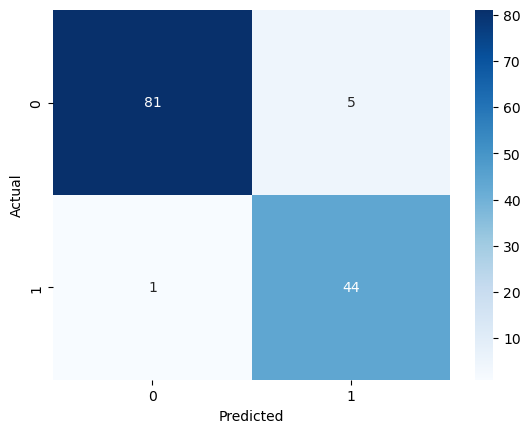

In [72]:
cm = confusion_matrix(y_test,bag_d_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC AUC: 0.9978036175710594


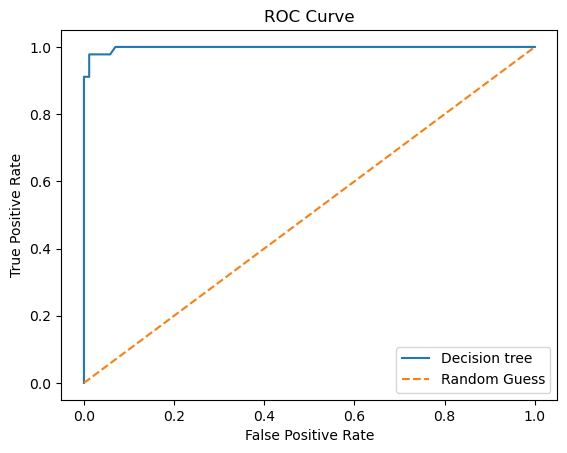

In [73]:
bag_d_proba_test = bag_d.predict_proba(X_test)[:, 1]


auc = roc_auc_score(y_test, bag_d_proba_test)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, bag_d_proba_test,pos_label='notckd')

plt.plot(fpr, tpr, label="Decision tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [74]:
#slightly worse then forest so gonna use bagging for forest 

In [75]:
bag_f = BaggingClassifier(
    estimator=forest,
    n_estimators=100,
    bootstrap=True
)


In [76]:
bag_f.fit(X_train,y_train)

,estimator,RandomForestC...r(max_depth=5)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [77]:
bag_f_test_pred = bag_f.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, bag_f_test_pred))

Test accuracy: 0.9465648854961832


In [78]:
print(classification_report(y_test, bag_f_test_pred))

              precision    recall  f1-score   support

         ckd       1.00      0.92      0.96        86
      notckd       0.87      1.00      0.93        45

    accuracy                           0.95       131
   macro avg       0.93      0.96      0.94       131
weighted avg       0.95      0.95      0.95       131



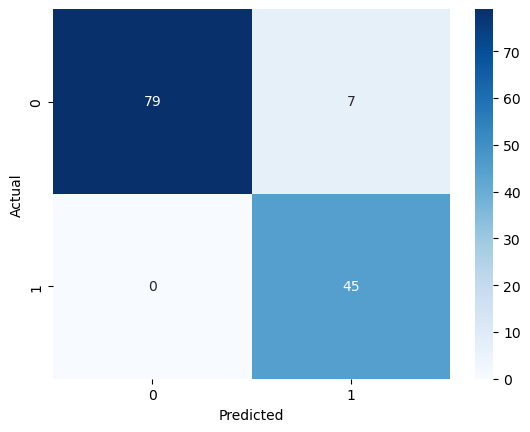

In [79]:
#slightly worse could just be luck though
cm = confusion_matrix(y_test,bag_f_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC AUC: 0.9994832041343669


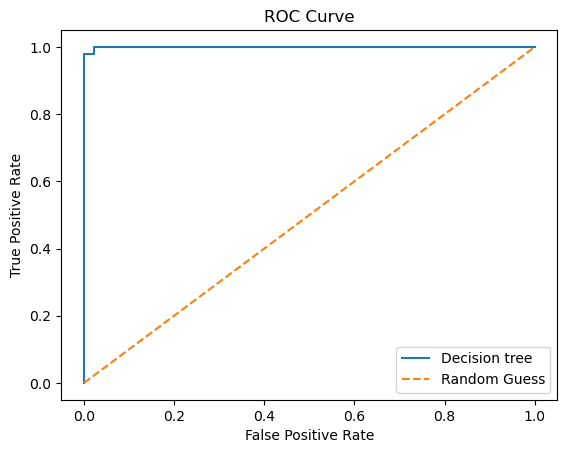

In [80]:
bag_f_proba_test = forest.predict_proba(X_test)[:, 1]


auc = roc_auc_score(y_test, bag_f_proba_test)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, bag_f_proba_test,pos_label='notckd')

plt.plot(fpr, tpr, label="Decision tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [81]:
#Boosting 

In [82]:

boosting = AdaBoostClassifier(estimator = forest)
boosting.fit(X_train,y_train)

,estimator,RandomForestC...r(max_depth=5)
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None
,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [83]:
boost_test_pred = boosting.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, boost_test_pred))

Test accuracy: 0.9465648854961832


In [95]:
print(classification_report(y_test, boost_test_pred))

              precision    recall  f1-score   support

         ckd       1.00      0.92      0.96        86
      notckd       0.87      1.00      0.93        45

    accuracy                           0.95       131
   macro avg       0.93      0.96      0.94       131
weighted avg       0.95      0.95      0.95       131



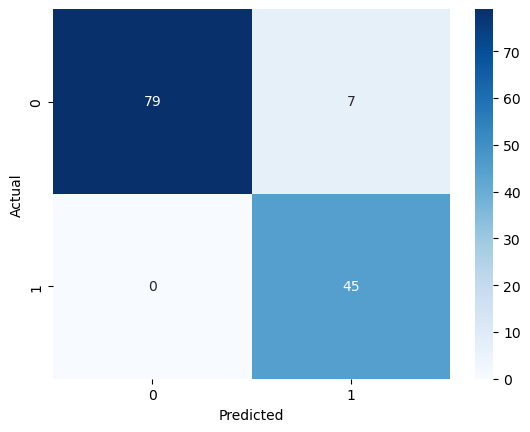

In [84]:
cm = confusion_matrix(y_test,boost_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC AUC: 0.9984496124031008


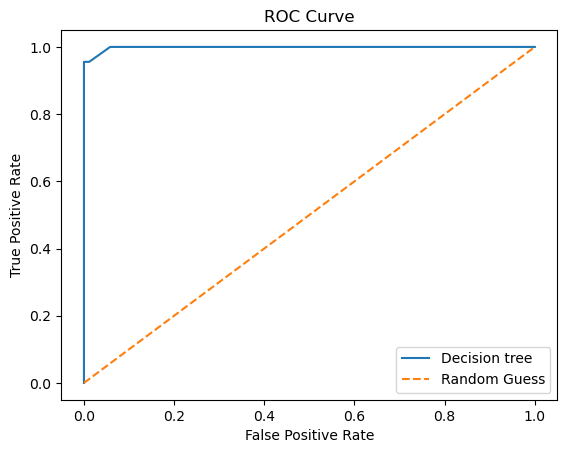

In [85]:
boost_proba_test = boosting.predict_proba(X_test)[:, 1]


auc = roc_auc_score(y_test, boost_proba_test)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, boost_proba_test,pos_label='notckd')

plt.plot(fpr, tpr, label="Decision tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [86]:
#stacking 

In [87]:
base_models = [
    ("lr", LogisticRegression()),
    ("dt", DecisionTreeClassifier()),
    ("svm", SVC(probability=True)),
    ('forest', RandomForestClassifier())
]

In [88]:
meta_model = LogisticRegression()

In [89]:
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

In [90]:
stack_model.fit(X_train_scaled, y_train) 

,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [91]:
stack_y_test_pred = stack_model.predict(X_test_scaled)
print("Test accuracy:", accuracy_score(y_test, stack_y_test_pred))

Test accuracy: 0.9694656488549618


In [96]:
print(classification_report(y_test, stack_y_test_pred))

              precision    recall  f1-score   support

         ckd       1.00      0.95      0.98        86
      notckd       0.92      1.00      0.96        45

    accuracy                           0.97       131
   macro avg       0.96      0.98      0.97       131
weighted avg       0.97      0.97      0.97       131



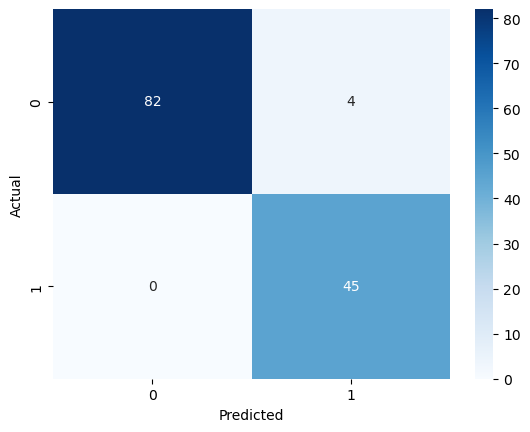

In [92]:
cm = confusion_matrix(y_test,stack_y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ROC AUC: 0.9976744186046512


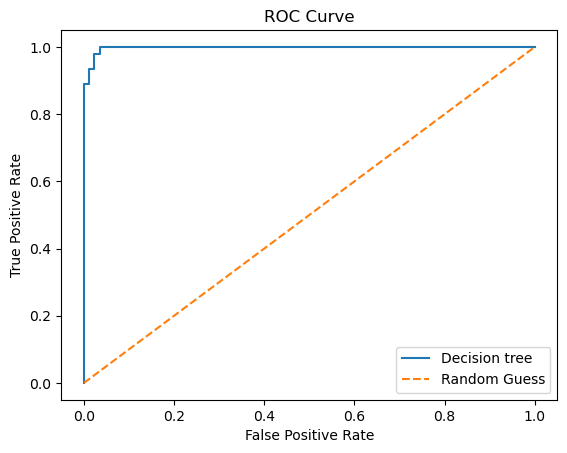

In [93]:
stack_y_proba_test = stack_model.predict_proba(X_test_scaled)[:, 1]


auc = roc_auc_score(y_test, stack_y_proba_test)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, stack_y_proba_test,pos_label='notckd')

plt.plot(fpr, tpr, label="Decision tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [97]:
#forest seems to be the best so quickly comparing them all
print("Stacking Test accuracy:", accuracy_score(y_test, stack_y_test_pred))
print("Boost Test accuracy:", accuracy_score(y_test, boost_test_pred))
print("Bagging Test accuracy:", accuracy_score(y_test, bag_f_test_pred))
print("Forest test accuracy:", accuracy_score(y_test, forest_test_pred))

Stacking Test accuracy: 0.9694656488549618
Boost Test accuracy: 0.9465648854961832
Bagging Test accuracy: 0.9465648854961832
Forest test accuracy: 0.9465648854961832


In [ ]:
#stacking seems to give it the slightest boost due to having other models
#Decision tree i would say gave the worst results as it had false negatives and that is something that we must try avoid more so then false positives